In [ ]:
from ultralytics import YOLO

model = YOLO('/Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/runs/detect/train/weights/best.pt')

results = model.predict('/Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/data/test/images/43.jpg', save=True, conf=0.5)

for r in results:
    print(r.boxes) 


image 1/1 /Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/data/test/images/43.jpg: 640x480 1 speedlimit, 101.8ms
Speed: 9.7ms preprocess, 101.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/runs/detect/predict
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([1.])
conf: tensor([0.8517])
data: tensor([[ 75.2991,  94.3198, 123.5616, 142.2440,   0.8517,   1.0000]])
id: None
is_track: False
orig_shape: (400, 300)
shape: torch.Size([1, 6])
xywh: tensor([[ 99.4303, 118.2819,  48.2625,  47.9242]])
xywhn: tensor([[0.3314, 0.2957, 0.1609, 0.1198]])
xyxy: tensor([[ 75.2991,  94.3198, 123.5616, 142.2440]])
xyxyn: tensor([[0.2510, 0.2358, 0.4119, 0.3556]])


Używane urządzenie: cpu


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



image 1/1 /Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/data/test/images/61.jpg: 640x480 1 stop, 1 trafficlight, 71.2ms
Speed: 1.9ms preprocess, 71.2ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 480)


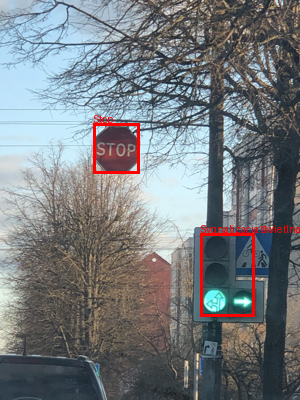

In [4]:
import torch
from ultralytics import YOLO
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image, ImageDraw
from gtts import gTTS
from IPython.display import Audio, display
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Używane urządzenie: {device}")

yolo_model_path = '/Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/runs/detect/train/weights/best.pt' 
model = YOLO(yolo_model_path).to(device)

processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model_ocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)

def predict_and_speak(img_path):
    results = model.predict(img_path, conf=0.5, device=device)
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)
    
    found_signs = []

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            class_id = int(box.cls)
            label = model.names[class_id]

            if label == 'speedlimit':
                crop = img.crop((max(0, x1-5), max(0, y1-5), x2+5, y2+5))
                pixel_values = processor(images=crop, return_tensors="pt").pixel_values.to(device)
                generated_ids = model_ocr.generate(pixel_values)
                text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
                
                clean_text = ''.join(filter(str.isdigit, text))
                display_label = f"Ograniczenie do {clean_text}" if clean_text else "Ograniczenie prędkości"
            else:
                labels_pl = {"stop": "Stop", "crosswalk": "Przejście dla pieszych", "trafficlight": "Sygnalizacja świetlna"}
                display_label = labels_pl.get(label, label)

            found_signs.append(display_label)
            draw.rectangle([x1, y1, x2, y2], outline="red", width=3)
            draw.text((x1, y1 - 10), display_label, fill="red")
    display(img)

    if found_signs:
        tekst_do_czytania = "Wykryto znak:" + ", ".join(found_signs)
        tts = gTTS(text=tekst_do_czytania, lang='pl')
        tts.save("audio.mp3")
        display(Audio("audio.mp3", autoplay=True))
    else:
        print("Nie wykryto żadnych znaków.")

predict_and_speak("/Users/sebastianstarzec/Documents/Magisterka/Semestr 4/projektNlp/data/test/images/61.jpg")

In [6]:
!pip install moviepy

In [ ]:
import cv2
import torch
import numpy as np
import os
from ultralytics import YOLO
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from PIL import Image, ImageDraw, ImageFont
from gtts import gTTS
from moviepy import VideoFileClip, AudioFileClip, CompositeAudioClip

device = "mps" if torch.backends.mps.is_available() else "cpu"
YOLO_PATH = '******/runs/detect/train/weights/best.pt'  # Ścieżka do wytrenowanego modelu YOLO
VIDEO_INPUT = 'nagranie.mp4' 
VIDEO_TEMP = 'temp_no_audio.mp4'
VIDEO_FINAL = 'nagranie_z_lektorem.mp4'

print(f"🚀 Inicjalizacja... Urządzenie: {device}")

# Ładowanie modeli
model_yolo = YOLO(YOLO_PATH).to(device)
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-printed')
model_ocr = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-printed').to(device)

try:
    font = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 30)
except:
    font = ImageFont.load_default()

cap = cv2.VideoCapture(VIDEO_INPUT)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(VIDEO_TEMP, fourcc, fps, (width, height))

audio_segments = []
last_spoken_time = -5.0  
frame_count = 0


while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    current_time_sec = frame_count / fps
    img_pil = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)
    
    results = model_yolo.predict(img_pil, conf=0.45, device=device, verbose=False)
    
    found_this_frame = []

    for r in results:
        for box in r.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            label = model_yolo.names[int(box.cls)]
            
            display_text = ""
            
            if label == 'speedlimit':
                crop = img_pil.crop((max(0, x1-5), max(0, y1-5), x2+5, y2+5))
                pixel_values = processor(images=crop, return_tensors="pt").pixel_values.to(device)
                generated_ids = model_ocr.generate(pixel_values)
                ocr_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
                
                liczba = ''.join(filter(str.isdigit, ocr_text))
                display_text = f"Ograniczenie {liczba}" if liczba else "Ograniczenie"
                found_this_frame.append(f"Ograniczenie prędkości do {liczba}" if liczba else "Ograniczenie prędkości")
            else:
                slownik = {"stop": "STOP", "crosswalk": "PASY", "trafficlight": "SWIATLA"}
                display_text = slownik.get(label, label.upper())
                found_this_frame.append(display_text)

            draw.rectangle([x1, y1, x2, y2], outline="red", width=5)

            draw.rectangle([x1, y1-35, x1+200, y1], fill="red")
            draw.text((x1 + 5, y1 - 32), display_text, fill="white", font=font)

    if found_this_frame and (current_time_sec - last_spoken_time > 3.5):
        unique_signs = list(set(found_this_frame))
        tekst = "Wykryto znak: " + ", ".join(unique_signs)
        
        audio_filename = f"audio_tmp_{frame_count}.mp3"
        tts = gTTS(text=tekst, lang='pl')
        tts.save(audio_filename)
        
        audio_segments.append((audio_filename, current_time_sec))
        last_spoken_time = current_time_sec
    final_frame = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    out.write(final_frame)
    
    frame_count += 1
    if frame_count % 50 == 0:
        print(f"⌛ Przetworzono {frame_count} klatek...")

cap.release()
out.release()



🚀 Inicjalizacja... Urządzenie: mps


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🎥 Rozpoczynam przetwarzanie klatek (może to chwilę potrwać)...
⌛ Przetworzono 50 klatek...
⌛ Przetworzono 100 klatek...
⌛ Przetworzono 150 klatek...
⌛ Przetworzono 200 klatek...
⌛ Przetworzono 250 klatek...
⌛ Przetworzono 300 klatek...
⌛ Przetworzono 350 klatek...
⌛ Przetworzono 400 klatek...
⌛ Przetworzono 450 klatek...
⌛ Przetworzono 500 klatek...
⌛ Przetworzono 550 klatek...
⌛ Przetworzono 600 klatek...
⌛ Przetworzono 650 klatek...
⌛ Przetworzono 700 klatek...
⌛ Przetworzono 750 klatek...
⌛ Przetworzono 800 klatek...
⌛ Przetworzono 850 klatek...
⌛ Przetworzono 900 klatek...
⌛ Przetworzono 950 klatek...
⌛ Przetworzono 1000 klatek...
⌛ Przetworzono 1050 klatek...


/opt/anaconda3/envs/traffic_vision/lib/python3.10/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/opt/anaconda3/envs/traffic_vision/lib/python3.10/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


...

/opt/anaconda3/envs/traffic_vision/lib/python3.10/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


⌛ Przetworzono 64150 klatek...
⌛ Przetworzono 64200 klatek...
⌛ Przetworzono 64250 klatek...
⌛ Przetworzono 64300 klatek...
⌛ Przetworzono 64350 klatek...
⌛ Przetworzono 64400 klatek...
⌛ Przetworzono 64450 klatek...
⌛ Przetworzono 64500 klatek...
⌛ Przetworzono 64550 klatek...
⌛ Przetworzono 64600 klatek...
⌛ Przetworzono 64650 klatek...
⌛ Przetworzono 64700 klatek...
⌛ Przetworzono 64750 klatek...


/opt/anaconda3/envs/traffic_vision/lib/python3.10/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/opt/anaconda3/envs/traffic_vision/lib/python3.10/site-packages/transformers/generation/utils.py:1569: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


⌛ Przetworzono 64800 klatek...
⌛ Przetworzono 64850 klatek...
⌛ Przetworzono 64900 klatek...
⌛ Przetworzono 64950 klatek...
⌛ Przetworzono 65000 klatek...
⌛ Przetworzono 65050 klatek...
⌛ Przetworzono 65100 klatek...
⌛ Przetworzono 65150 klatek...
⌛ Przetworzono 65200 klatek...
⌛ Przetworzono 65250 klatek...
⌛ Przetworzono 65300 klatek...
⌛ Przetworzono 65350 klatek...
⌛ Przetworzono 65400 klatek...
⌛ Przetworzono 65450 klatek...
⌛ Przetworzono 65500 klatek...
⌛ Przetworzono 65550 klatek...
⌛ Przetworzono 65600 klatek...
⌛ Przetworzono 65650 klatek...
🔊 Składanie ścieżki dźwiękowej...


AttributeError: 'AudioFileClip' object has no attribute 'set_start'

In [ ]:

from moviepy import VideoFileClip, AudioFileClip, CompositeAudioClip

print("🔊 Składanie ścieżki dźwiękowej...")

video_clip = VideoFileClip(VIDEO_TEMP)
audio_clips = []

for filename, start_time in audio_segments:
    a_clip = AudioFileClip(filename).with_start(start_time)
    audio_clips.append(a_clip)

if audio_clips:
    final_audio = CompositeAudioClip(audio_clips)
    
    video_clip = video_clip.with_audio(final_audio)

print("🎬 Renderowanie finalnego pliku (to może potrwać)...")
video_clip.write_videofile(VIDEO_FINAL, codec='libx264')

video_clip.close()

for filename, _ in audio_segments:
    if os.path.exists(filename):
        os.remove(filename)
if os.path.exists(VIDEO_TEMP):
    os.remove(VIDEO_TEMP)


🔊 Składanie ścieżki dźwiękowej...
🎬 Renderowanie finalnego pliku (to może potrwać)...
MoviePy - Building video nagranie_z_lektorem.mp4.
MoviePy - Writing audio in nagranie_z_lektoremTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
MoviePy - Writing video nagranie_z_lektorem.mp4



MoviePy - Done !
MoviePy - video ready nagranie_z_lektorem.mp4
🧹 Sprzątanie plików tymczasowych...
🎉 GOTOWE! Wynik znajdziesz w: nagranie_z_lektorem.mp4
